# DigiCow Farmer Adoption Prediction

**Competition:** DigiCow Farmer Adoption Prediction - Zindi Africa
**Goal:** Predict the probability that a farmer adopts an agricultural practice

within 7, 90, and 120 days of attending a training session, using only
information available at the time of training.

**Approach:** We build interpretable models that produce probability scores
for each prediction window. The focus throughout is on features and decisions
that can be explained to a non-technical audience.

---

### Data Available

| File | Description |
|---|---|
| `Train.csv` | Labelled training records: farmers with known adoption outcomes |
| `Test.csv` | Unlabelled records: farmers whose adoption we predict |
| `Prior.csv` | Historical training records from an earlier period: used for feature construction |

### Notebook Structure

| Section | Content |
|---|---|
| 1 | Data loading and sanity checks |
| 2 | Exploratory data analysis |
| 3 | Feature engineering |
| 4 | Logistic Regression models with odds ratios |
| 5 | Decision Tree models with visualisation |
| 6 | Classifier Chain - exploiting target structure |
| 7 | Model comparison |
| 8 | Interpretation |

### Libraries 

`pandas` is used throughout this notebook for data manipulation. All datasets are loaded and processed as `pandas` DataFrames.

`numpy` supports numerical operations used in feature engineering and metric calculations.

`matplotlib` is the base plotting library. All charts in this notebook are built using `matplotlib` figures and axis

`seaborn` sits on top of `matplotlib` and simplifies grouped bar charts and heatmaps. 

`os` is used to create the figures folder if it does not already exist.

`ast` is used to parse the topics column, which is stored as a string
representation of a Python list.

In [38]:
# ── Libraries ─────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


# ── Output folder ─────────────────────────────────────────────────────────────
# All charts are saved here so they can be referenced in the README.
os.makedirs('figures', exist_ok=True)

# ── Reproducibility ───────────────────────────────────────────────────────────
# Any function that involves randomness accepts a random_state parameter.
# Passing the same integer every time ensures results are identical across runs.
RANDOM_SEED = 42



# ── Display settings ──────────────────────────────────────────────────────────
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
pd.set_option('display.max_rows', 100)

print("Libraries loaded.")


Libraries loaded.


## 1. Data Loading and Initial Overview

We load all three files and verify they match expectations. This section establishes that the data is intact and that the relationship between the three files is what we expect.

The three files serve different purposes:
- `Train.csv` is used to train the models, it contains known outcomes
- `Test.csv` contains farmers whose adoption we need to predict
- `Prior.csv` contains historical records from an earlier period. We will use this in Section 3 to build features without leaking information about the outcomes we are predicting

In [39]:
train_df = pd.read_csv('Train.csv')
test_df = pd.read_csv('Test.csv')
prior_df = pd.read_csv('Prior.csv')

print("Files loaded.")
print(f"  Train : {train_df.shape[0]:,} rows  {train_df.shape[1]} columns")
print(f"  Test  : {test_df.shape[0]:,} rows  {test_df.shape[1]} columns")
print(f"  Prior : {prior_df.shape[0]:,} rows  {prior_df.shape[1]} columns")

Files loaded.
  Train : 13,536 rows  17 columns
  Test  : 5,621 rows  14 columns
  Prior : 44,882 rows  17 columns


In [40]:
print("=== TEST COLUMNS ===")
for col in test_df.columns:
    print(f"  {col}")
print(f"Shape: {test_df.shape}")

print("=== TRAIN COLUMNS ===")
for col in train_df.columns:
    print(f"  {col}")
print(f"Shape: {train_df.shape}")

print("\n=== PRIOR COLUMNS ===")
for col in prior_df.columns:
    print(f"  {col}")
print(f"Shape: {prior_df.shape}")

print("\n=== PRIOR SAMPLE ===")
print(prior_df.head(3).to_string())

=== TEST COLUMNS ===
  ID
  farmer_name
  training_day
  gender
  registration
  age
  group_name
  belong_to_cooperative
  county
  subcounty
  ward
  has_topic_trained_on
  trainer
  topics_list
Shape: (5621, 14)
=== TRAIN COLUMNS ===
  ID
  farmer_name
  training_day
  gender
  registration
  age
  group_name
  belong_to_cooperative
  county
  subcounty
  ward
  adopted_within_07_days
  adopted_within_90_days
  adopted_within_120_days
  has_topic_trained_on
  trainer
  topics_list
Shape: (13536, 17)

=== PRIOR COLUMNS ===
  ID
  farmer_name
  training_day
  gender
  registration
  age
  group_name
  belong_to_cooperative
  county
  subcounty
  ward
  adopted_within_07_days
  adopted_within_90_days
  adopted_within_120_days
  has_topic_trained_on
  trainer
  topics_list
Shape: (44882, 17)

=== PRIOR SAMPLE ===
          ID  farmer_name training_day  gender registration       age   group_name  belong_to_cooperative      county    subcounty          ward  adopted_within_07_days  adopte

### 1.3 Data Types and Missing Values

We inspect each dataset for two things:

(i) how each column is stored

(ii) whether any values are missing. 


In [41]:
print("=== Train ===")
train_df.info()

print("\n=== Test ===")
test_df.info()

print("\n=== Prior ===")
prior_df.info()

=== Train ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13536 entries, 0 to 13535
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   ID                       13536 non-null  object
 1   farmer_name              13536 non-null  object
 2   training_day             13536 non-null  object
 3   gender                   13536 non-null  object
 4   registration             13536 non-null  object
 5   age                      13536 non-null  object
 6   group_name               13536 non-null  object
 7   belong_to_cooperative    13536 non-null  int64 
 8   county                   13536 non-null  object
 9   subcounty                13536 non-null  object
 10  ward                     13536 non-null  object
 11  adopted_within_07_days   13536 non-null  int64 
 12  adopted_within_90_days   13536 non-null  int64 
 13  adopted_within_120_days  13536 non-null  int64 
 14  has_topic_trained_on    

In [42]:
# Checking for missing values in train and test datasets
print("=== Missing Values — Train ===")
missing = train_df.isnull().sum() # counts missing values per column
missing_pct = (missing / len(train_df) * 100).round(2) # Percentage of missing values per column
print(pd.DataFrame({'missing_count': missing,
                    'missing_pct': missing_pct})
      [missing > 0])

print("\n=== Missing Values — Test ===")
missing = test_df.isnull().sum()
missing_pct = (missing / len(test_df) * 100).round(2)
print(pd.DataFrame({'missing_count': missing,
                    'missing_pct': missing_pct})
      [missing > 0])

=== Missing Values — Train ===
Empty DataFrame
Columns: [missing_count, missing_pct]
Index: []

=== Missing Values — Test ===
Empty DataFrame
Columns: [missing_count, missing_pct]
Index: []


No missing values were found in either Train or Test. This means every row is complete and no imputation is needed before modelling.

In [43]:
# Check exact values in the registration column
print(train_df['registration'].value_counts())

# Check the topics_list — first 3 values
print()
for val in train_df['topics_list'].head(3):
    print(val)
    print()

# Check Prior adoption column name and a sample
print(prior_df[['trainer', 'county', 'adopted_within_120_days']].head(3))

registration
Ussd      8383
Manual    5153
Name: count, dtype: int64

[['Ndume App', 'Poultry Feeding']]

[['Poultry Housing'], ['Poultry Housing']]

[['Asili Fertilizer (Organic)', 'Biosecurity In Poultry Farming', 'Calf Feeding', 'Dairy Health Management', 'Dairy Nutrition With Tyari', 'Diseases In Dairy Farming', 'Feeding A Lactating Cow', 'How To Feed Kienyeji Chicken For Meat', 'How To Feed Kienyeji Chicken From 1 Day Old To Maturity', 'How To Feed Layers From 1 Day Old To Maturity', 'How To Rear A Calf With Unga Products', 'How To Rear Healthy Chicken With Biodeal.', 'Importance Of Choosing The Right Seed Variety', 'Importance Of Vaccinations And Record', 'Milking Hygiene', 'Personal Protective Equipment (Ppe)', 'Pest And Disease Management In Maize And Beans', 'Poultry And Dairy Feeding With Tyari Feeds', 'Poultry Diseases And Biosecurity', 'Poultry Feeding', 'Poultry Feeding With Tyari', 'Poultry Health Management', 'Poultry Housing', 'Poultry Products', 'Record Keeping In Dair

In [44]:
# ── Reusable summary function ─────────────────────────────────────────────────
# Defined once, called on all three DataFrames

def summarise_dataframe(df, name):
    """
    Returns a column-level audit table.
    
    Parameters
    ----------
    df   : pd.DataFrame
    name : str — label for the printed header
    """
    summary = pd.DataFrame({
        'dtype'         : df.dtypes,
        'missing_count' : df.isnull().sum(),
        'missing_pct'   : (df.isnull().sum() / len(df) * 100).round(2),
        'n_unique'      : df.nunique(),
        'has_missing'   : df.isnull().sum() > 0
    })

    print(f"\n{'═' * 60}")
    print(f"  {name}  |  {df.shape[0]:,} rows  ×  {df.shape[1]} columns")
    print(f"{'═' * 60}")
    return summary

train_summary = summarise_dataframe(train_df, "Train.csv")
display(train_summary)

test_summary = summarise_dataframe(test_df, "Test.csv")
display(test_summary)

prior_summary = summarise_dataframe(prior_df, "Prior.csv")
display(prior_summary)


════════════════════════════════════════════════════════════
  Train.csv  |  13,536 rows  ×  17 columns
════════════════════════════════════════════════════════════


,dtype,missing_count,missing_pct,n_unique,has_missing
ID,object,0,0.0000,13536,False
farmer_name,object,0,0.0000,13536,False
training_day,object,0,0.0000,152,False
gender,object,0,0.0000,2,False
registration,object,0,0.0000,2,False
age,object,0,0.0000,2,False
group_name,object,0,0.0000,864,False
belong_to_cooperative,int64,0,0.0000,2,False
county,object,0,0.0000,8,False
subcounty,object,0,0.0000,26,False



════════════════════════════════════════════════════════════
  Test.csv  |  5,621 rows  ×  14 columns
════════════════════════════════════════════════════════════


,dtype,missing_count,missing_pct,n_unique,has_missing
ID,object,0,0.0000,5621,False
farmer_name,object,0,0.0000,5621,False
training_day,object,0,0.0000,78,False
gender,object,0,0.0000,2,False
registration,object,0,0.0000,2,False
age,object,0,0.0000,2,False
group_name,object,0,0.0000,239,False
belong_to_cooperative,int64,0,0.0000,2,False
county,object,0,0.0000,7,False
subcounty,object,0,0.0000,16,False



════════════════════════════════════════════════════════════
  Prior.csv  |  44,882 rows  ×  17 columns
════════════════════════════════════════════════════════════


,dtype,missing_count,missing_pct,n_unique,has_missing
ID,object,0,0.0000,44882,False
farmer_name,object,0,0.0000,6719,False
training_day,object,0,0.0000,224,False
gender,object,0,0.0000,2,False
registration,object,0,0.0000,2,False
age,object,0,0.0000,2,False
group_name,object,0,0.0000,840,False
belong_to_cooperative,int64,0,0.0000,2,False
county,object,0,0.0000,9,False
subcounty,object,0,0.0000,28,False


In [51]:
# ── Clean trainer column ──────────────────────────────────────────────────────
# A small number of rows have multiple trainers stored as a list string
# We extract only the first trainer for simplicity
import ast

def extract_first_trainer(val):
    """
    Extract first trainer from value.
    Handles both plain strings like 'TRA_abc' 
    and list strings like "['TRA_abc', 'TRA_xyz']"
    """
    if pd.isna(val):
        return val
    try:
        parsed = ast.literal_eval(str(val))
        if isinstance(parsed, list):
            return parsed[0]   # take first trainer only
    except:
        pass
    return str(val)

# Apply to all three dataframes
train_df['trainer'] = train_df['trainer'].apply(extract_first_trainer)
test_df['trainer']  = test_df['trainer'].apply(extract_first_trainer)
prior_df['trainer'] = prior_df['trainer'].apply(extract_first_trainer)

# Verify
print("Unique trainers in Train:", train_df['trainer'].nunique())
print("Sample values:", train_df['trainer'].unique()[:5])

Unique trainers in Train: 9
Sample values: ['TRA_szrwyfzz' 'TRA_rkvyofbh' 'TRA_gertumxc' 'TRA_hyodnntj'
 'TRA_suiifsur']


## 2. Exploratory Data Analysis

Before building any model we examine the data to understand patterns and 
identify which features are likely to be predictive. All findings here 
directly inform the feature engineering decisions in Section 3.

### 2.1 Target Distribution

The three targets are severely imbalanced; very few farmers adopt within 
any time window. We quantify this imbalance before modelling because it 
directly affects which models and evaluation metrics we use.

In [45]:
# ── 2.1 Target Distribution ───────────────────────────────────────────────────
TARGET_COLS = [
    'adopted_within_07_days',
    'adopted_within_90_days',
    'adopted_within_120_days'
]

# Count adopters and non-adopters per target
target_summary = []
for col in TARGET_COLS:
    total        = len(train_df)
    adopted      = train_df[col].sum()
    not_adopted  = total - adopted
    rate         = adopted / total * 100
    ratio        = not_adopted / adopted

    target_summary.append({
        'Target'          : col.replace('adopted_within_', '').replace('_days', 'd'),
        'Total'           : total,
        'Adopted'         : adopted,
        'Not Adopted'     : not_adopted,
        'Adoption Rate %' : round(rate, 2),
        'Imbalance Ratio' : f'{ratio:.0f}:1'
    })

summary_df = pd.DataFrame(target_summary).set_index('Target')
display(summary_df)

,Total,Adopted,Not Adopted,Adoption Rate %,Imbalance Ratio
Target,,,,,
07d,13536,153,13383,1.1300,87:1
90d,13536,214,13322,1.5800,62:1
120d,13536,302,13234,2.2300,44:1


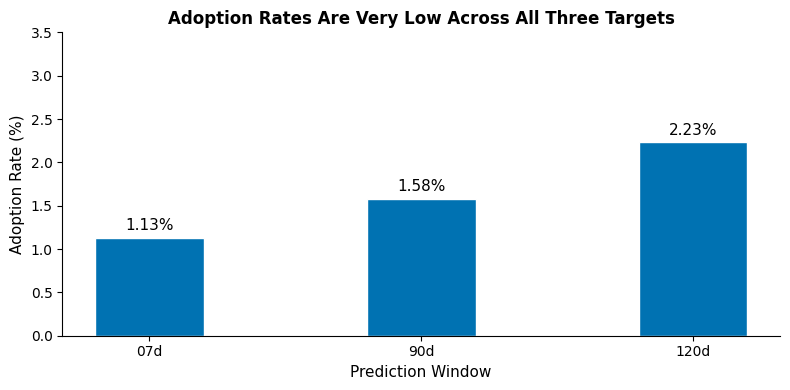

Chart saved to figures/01_target_distribution.png


In [46]:
# ── Chart: Adoption rates across three targets ────────────────────────────────
# Wong colorblind-safe palette
BLUE      = '#0072B2'
VERMILLION = '#D55E00'
GREEN     = '#009E73'

fig, ax = plt.subplots(figsize=(8, 4))

targets  = ['07d', '90d', '120d']
rates    = [1.13, 1.58, 2.23]
colours  = [BLUE, BLUE, BLUE]

bars = ax.bar(targets, rates, color=colours, width=0.4, edgecolor='white')

# Add value labels on top of each bar
for bar, rate in zip(bars, rates):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f'{rate}%',
        ha='center', va='bottom', fontsize=11
    )

ax.set_xlabel('Prediction Window', fontsize=11)
ax.set_ylabel('Adoption Rate (%)', fontsize=11)
ax.set_title('Adoption Rates Are Very Low Across All Three Targets',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, 3.5)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('figures/01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved to figures/01_target_distribution.png")

### 2.2 Adoption Rates by Key Features

We examine how adoption rates vary across four categorical features:
gender, age group, registration method and cooperative membership.
Features with large differences between categories are likely to be
useful predictors.

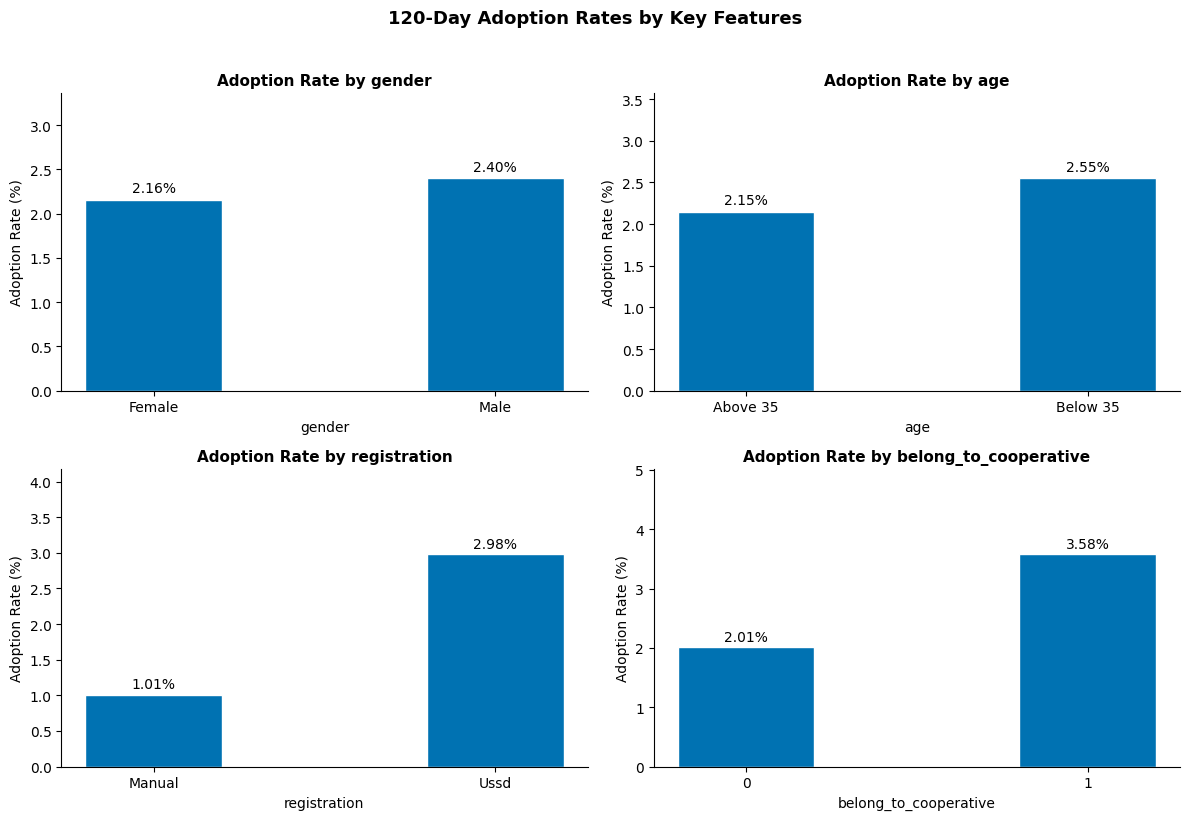

Chart saved.


In [47]:
# ── 2.2 Adoption rates by categorical features ───────────────────────────────
# Features to examine
CAT_FEATURES = ['gender', 'age', 'registration', 'belong_to_cooperative']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(CAT_FEATURES):
    # Calculate mean adoption rate per category for 120-day target
    rates = (train_df.groupby(feature)['adopted_within_120_days']
             .mean()
             .mul(100)
             .round(2)
             .reset_index())
    rates.columns = ['category', 'adoption_rate']

    # Plot
    axes[i].bar(
        rates['category'].astype(str),
        rates['adoption_rate'],
        color=BLUE,
        edgecolor='white',
        width=0.4
    )

    # Value labels
    for bar in axes[i].patches:
        axes[i].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.05,
            f'{bar.get_height():.2f}%',
            ha='center', va='bottom', fontsize=10
        )

    axes[i].set_title(f'Adoption Rate by {feature}',
                      fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Adoption Rate (%)', fontsize=10)
    axes[i].set_xlabel(feature, fontsize=10)
    axes[i].set_ylim(0, rates['adoption_rate'].max() * 1.4)
    axes[i].spines[['top', 'right']].set_visible(False)

plt.suptitle('120-Day Adoption Rates by Key Features',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/02_adoption_by_features.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved.")

Cooperative membership and registration method show the strongest association
with adoption. Farmers who belong to a cooperative adopt at 78% higher rates
than non-members. USSD-registered farmers adopt at nearly three times the rate
of manually registered farmers. Gender and age show minimal differences and
are unlikely to be strong predictors.

### 2.3 Trainer Effectiveness

Adoption rates vary significantly across trainers. A trainer who consistently
achieves higher adoption rates is a strong signal worth capturing. We examine
this variation here to justify using trainer historical rates as a feature.

     trainer  farmer_count  adoption_rate
TRA_kkzpfdtu           734         5.3100
TRA_szrwyfzz          2028         4.6400
TRA_twwcfcum            24         4.1700
TRA_rkvyofbh          1877         3.6800
TRA_hyodnntj          2168         2.9100
TRA_gertumxc          3049         0.7900
TRA_ubcgvofe          1456         0.6200
TRA_suiifsur          2190         0.1400
TRA_dttdgplk            10         0.0000


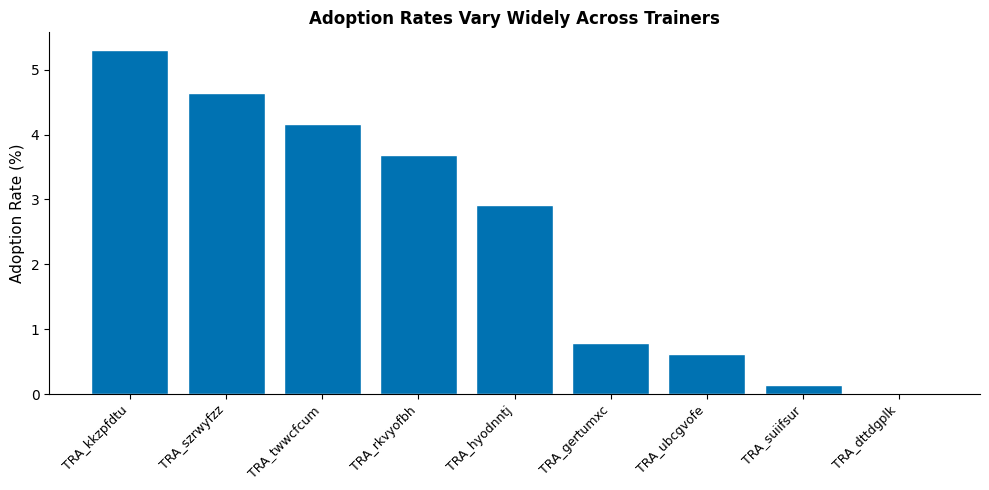

In [50]:
# ── 2.3 Trainer effectiveness ─────────────────────────────────────────────────
trainer_stats = (train_df.groupby('trainer')
                 .agg(
                     farmer_count   = ('ID', 'count'),
                     adoption_rate  = ('adopted_within_120_days', 'mean')
                 )
                 .reset_index())

trainer_stats['adoption_rate'] = (trainer_stats['adoption_rate'] * 100).round(2)

# Sort by adoption rate
trainer_stats = trainer_stats.sort_values('adoption_rate', ascending=False)

print(trainer_stats.to_string(index=False))

# Chart
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    range(len(trainer_stats)),
    trainer_stats['adoption_rate'],
    color=BLUE,
    edgecolor='white'
)

ax.set_xticks(range(len(trainer_stats)))
ax.set_xticklabels(trainer_stats['trainer'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Adoption Rate (%)', fontsize=11)
ax.set_title('Adoption Rates Vary Widely Across Trainers',
             fontsize=12, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('figures/03_trainer_effectiveness.png', dpi=150, bbox_inches='tight')
plt.show()

Trainer identity shows considerable variation in adoption rates, ranging 
from 5.31% for the most effective trainer to near zero for the least 
effective. This suggests that trainer quality or style meaningfully 
influences whether farmers adopt practices. We will encode this as a 
smoothed historical rate in Section 3 rather than as a dummy variable, 
to avoid creating sparse columns for trainers with few records.

### 2.4 County-Level Adoption Patterns

Adoption rates vary across counties. Since county identity may reflect 
differences in agricultural culture, trainer assignment, or cooperative 
density, it is worth examining as a potential predictor.

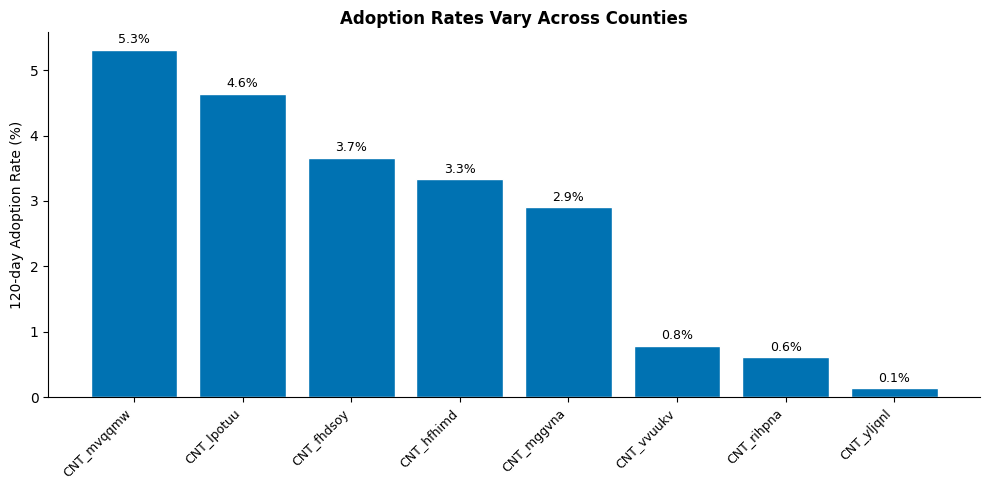

,county,farmer_count,rate_120
0,CNT_mvqqmw,734,5.3100
1,CNT_lpotuu,2028,4.6400
2,CNT_fhdsoy,1887,3.6600
3,CNT_hfhimd,30,3.3300
4,CNT_mggvna,2168,2.9100
5,CNT_vvuukv,3049,0.7900
6,CNT_rihpna,1450,0.6200
7,CNT_yljqnl,2190,0.1400


In [52]:
# ── 2.4 County adoption rates ─────────────────────────────────────────────────
county_stats = (train_df.groupby('county')
                .agg(
                    farmer_count=('ID', 'count'),
                    rate_120=('adopted_within_120_days', 'mean')
                )
                .reset_index())

county_stats['rate_120'] = (county_stats['rate_120'] * 100).round(2)
county_stats = county_stats.sort_values('rate_120', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    range(len(county_stats)),
    county_stats['rate_120'],
    color=BLUE,
    edgecolor='white'
)

# Value labels
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f'{bar.get_height():.1f}%',
        ha='center', va='bottom', fontsize=9
    )

ax.set_xticks(range(len(county_stats)))
ax.set_xticklabels(county_stats['county'], rotation=45,
                   ha='right', fontsize=9)
ax.set_ylabel('120-day Adoption Rate (%)', fontsize=10)
ax.set_title('Adoption Rates Vary Across Counties',
             fontsize=12, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('figures/04_county_adoption.png', dpi=150, bbox_inches='tight')
plt.show()

display(county_stats.reset_index(drop=True))

County-level adoption rates range from 5.31% to 0.14%, which is a 37x  difference. The pattern closely mirrors the trainer effectiveness 
results, which suggests that trainer assignment and county are 
correlated. Counties with few farmers produce unreliable raw rates. 


### 2.5 Topic Analysis

Each training session covers one or more topics. We examine how many 
topics are covered per session and which individual topics are 
associated with higher adoption rates.

In [53]:
# ── 2.5 Topic analysis ────────────────────────────────────────────────────────
import ast

def parse_topics(topic_str):
    """
    Parse topics_list string into a flat deduplicated list of topic strings.
    Handles nested list format: [['topic1', 'topic2'], ['topic1']]
    Deduplicates within a single session.
    """
    if pd.isna(topic_str):
        return []
    try:
        parsed = ast.literal_eval(str(topic_str))
        flat = []
        for item in parsed:
            if isinstance(item, list):
                flat.extend([t.strip() for t in item])
            else:
                flat.append(str(item).strip())
        return list(set(flat))   # deduplicate within session
    except:
        return []

# Parse topics for train
train_topics = train_df['topics_list'].apply(parse_topics)

# Topic count per session
train_df['n_topics'] = train_topics.apply(len)

print("Topics per session:")
print(train_df['n_topics'].describe().round(2))

Topics per session:
count   13536.0000
mean        3.0100
std         2.2300
min         1.0000
25%         2.0000
50%         3.0000
75%         4.0000
max        33.0000
Name: n_topics, dtype: float64


In [54]:
# ── Topic adoption rates ──────────────────────────────────────────────────────
# For each unique topic find how many farmers were trained on it
# and what proportion adopted within 120 days

from collections import Counter

# Build one row per farmer-topic pair
topic_records = []
for idx, topics in train_topics.items():
    outcome = train_df.loc[idx, 'adopted_within_120_days']
    for topic in topics:
        topic_records.append({
            'topic'   : topic,
            'adopted' : outcome
        })

topic_df = pd.DataFrame(topic_records)

# Aggregate per topic
topic_stats = (topic_df.groupby('topic')
               .agg(
                   farmer_count=('adopted', 'count'),
                   adoption_rate=('adopted', 'mean')
               )
               .reset_index())

# Keep only topics with at least 20 farmers
topic_stats = topic_stats[topic_stats['farmer_count'] >= 20].copy()
topic_stats['adoption_rate'] = (topic_stats['adoption_rate'] * 100).round(2)
topic_stats = topic_stats.sort_values('adoption_rate', ascending=False)

# Show top 15
print("Top 15 topics by 120-day adoption rate:")
display(topic_stats.head(15).reset_index(drop=True))

Top 15 topics by 120-day adoption rate:


,topic,farmer_count,adoption_rate
0,Poultry Health With Biodeal,74,24.3200
1,Livestock Management Practices,40,17.5000
2,Deworming And Record Keeping In Animal Health,423,13.9500
3,Why You Should Vaccinate Your Animals,425,13.4100
4,Herd. Health. Management,481,11.6400
5,Diseases In Dairy Farming,739,11.1000
6,Importance Of Mineral Supplementation,239,10.8800
7,Poultry Health Management,772,10.4900
8,Dairy Health Management,805,10.3100
9,Poultry Health Management. Practices,446,9.1900


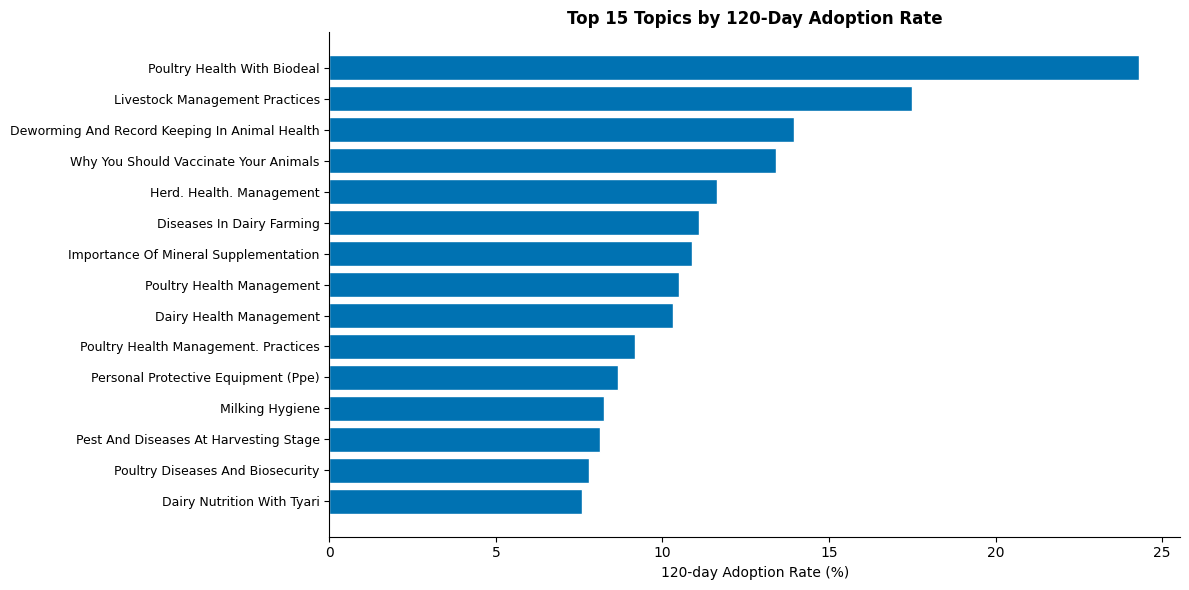

In [55]:
# ── Chart: Top 15 topics ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

top15 = topic_stats.head(15)

ax.barh(
    range(len(top15)),
    top15['adoption_rate'],
    color=BLUE,
    edgecolor='white'
)

ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15['topic'], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('120-day Adoption Rate (%)', fontsize=10)
ax.set_title('Top 15 Topics by 120-Day Adoption Rate',
             fontsize=12, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('figures/05_topic_adoption.png', dpi=150, bbox_inches='tight')
plt.show()

Topic content is strongly associated with adoption. Health-focused topics such as poultry health, deworming and vaccination consistently show the highest adoption rates with most exceeding 10%. This likely reflects that health interventions produce visible results quickly, giving farmers immediate motivation to adopt. We encode topic content as a smoothed historical adoption rate in Section 3.